# Imports and display settings

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Show ALL columns when we print a DataFrame (pandas hides some by default)
pd.set_option('display.max_columns', None)

# Consistent, clean look for all our plots
sns.set_style('whitegrid')

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


# Load the dataset

In [2]:
# Load the raw churn data into a DataFrame
df = pd.read_csv("../data/raw/telco_churn.csv")

print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (7043, 21)


# Peek at the actual rows

In [3]:
# View the first 5 rows to see what the data actually looks like
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# The X-ray

In [4]:
# Structural summary: column names, non-null counts, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Confirm what's hidden in 'TotalCharges'

In [5]:
# Try to convert TotalCharges to numeric; 'coerce' turns any unconvertible value into NaN (missing)
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count how many values FAILED to convert become (NaN)
failed_count = total_charges_numeric.isna().sum()
print(f"Values that couldn't convert to a number: {failed_count}")

# Look at the actual rows where it failed
df[total_charges_numeric.isna()]

Values that couldn't convert to a number: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


# Check for duplicates

In [6]:
# Count fully identical rows
print(f"Fully duplicate rows: {df.duplicated().sum()}")

# Count repeated customer IDs (each customer should appear exactly once)
print(f"Duplicate customer IDs: {df['customerID'].duplicated().sum()}")

Fully duplicate rows: 0
Duplicate customer IDs: 0


# Check for missing values

In [7]:
# Count missing (NaN) values in every column
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Make the cleaning decision and then fix it

In [8]:
# Step 1: Convert the text column to numeric - the 11 blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Fill those NaNs with 0 (tenure=0 -> no charges accrued yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Verify the fix worked
print(f"New dtype: {df['TotalCharges'].dtype}")
print(f"Missing values now: {df['TotalCharges'].isna().sum()}")

New dtype: float64
Missing values now: 0


# Scan the categorical columns for hidden quirks

In [9]:
# Show the unique values of every text (object) column
for col in df.select_dtypes(include='object').columns:
    print(f"{col} -> {df[col].unique()}")
    print("-" * 60)

customerID -> <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
------------------------------------------------------------
gender -> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------------------------------------------
Partner -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
------------------------------------------------------------
Dependents -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
------------------------------------------------------------
PhoneService -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
------------------------------------------------------------
MultipleLines -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----------

C:\Users\himan\AppData\Local\Temp\ipykernel_15656\1574136892.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## 🧹 Cleaning Decisions (→ feed into preprocessing module)

1. **TotalCharges**: stored as text due to 11 blank values (all `tenure=0`).
   → Convert to numeric, fill the 11 blanks with `0` (no charges accrued yet).
2. **customerID**: unique identifier, no predictive value → DROP before modeling.
3. **SeniorCitizen**: stored as 0/1 int while other binaries are Yes/No → standardize later.
4. **"No internet service" / "No phone service"**: redundant with "No"
   → optionally collapse to "No" in preprocessing.
5. **Duplicates**: none found (rows or customer IDs).
6. **Formal NaNs**: none — but missingness was hiding as blank strings (lesson learned).

# The target variable and the imbalance lesson

Counts: Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages(%): Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


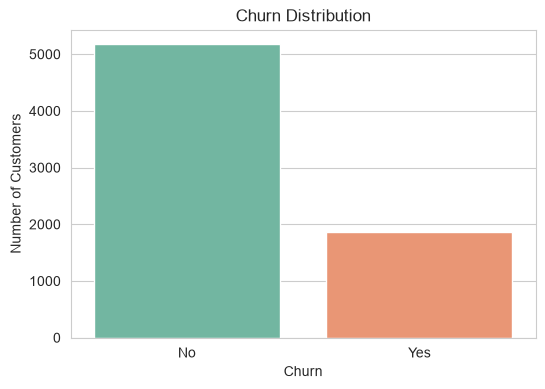

In [10]:
# Counts and percentages of each churn class
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"Counts: {churn_counts}")
print(f"\nPercentages(%): {churn_pct.round(2)}")

# Visulaize the balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.ylabel('Number of Customers')
plt.show()

# Numeric feature distributions, split by churn

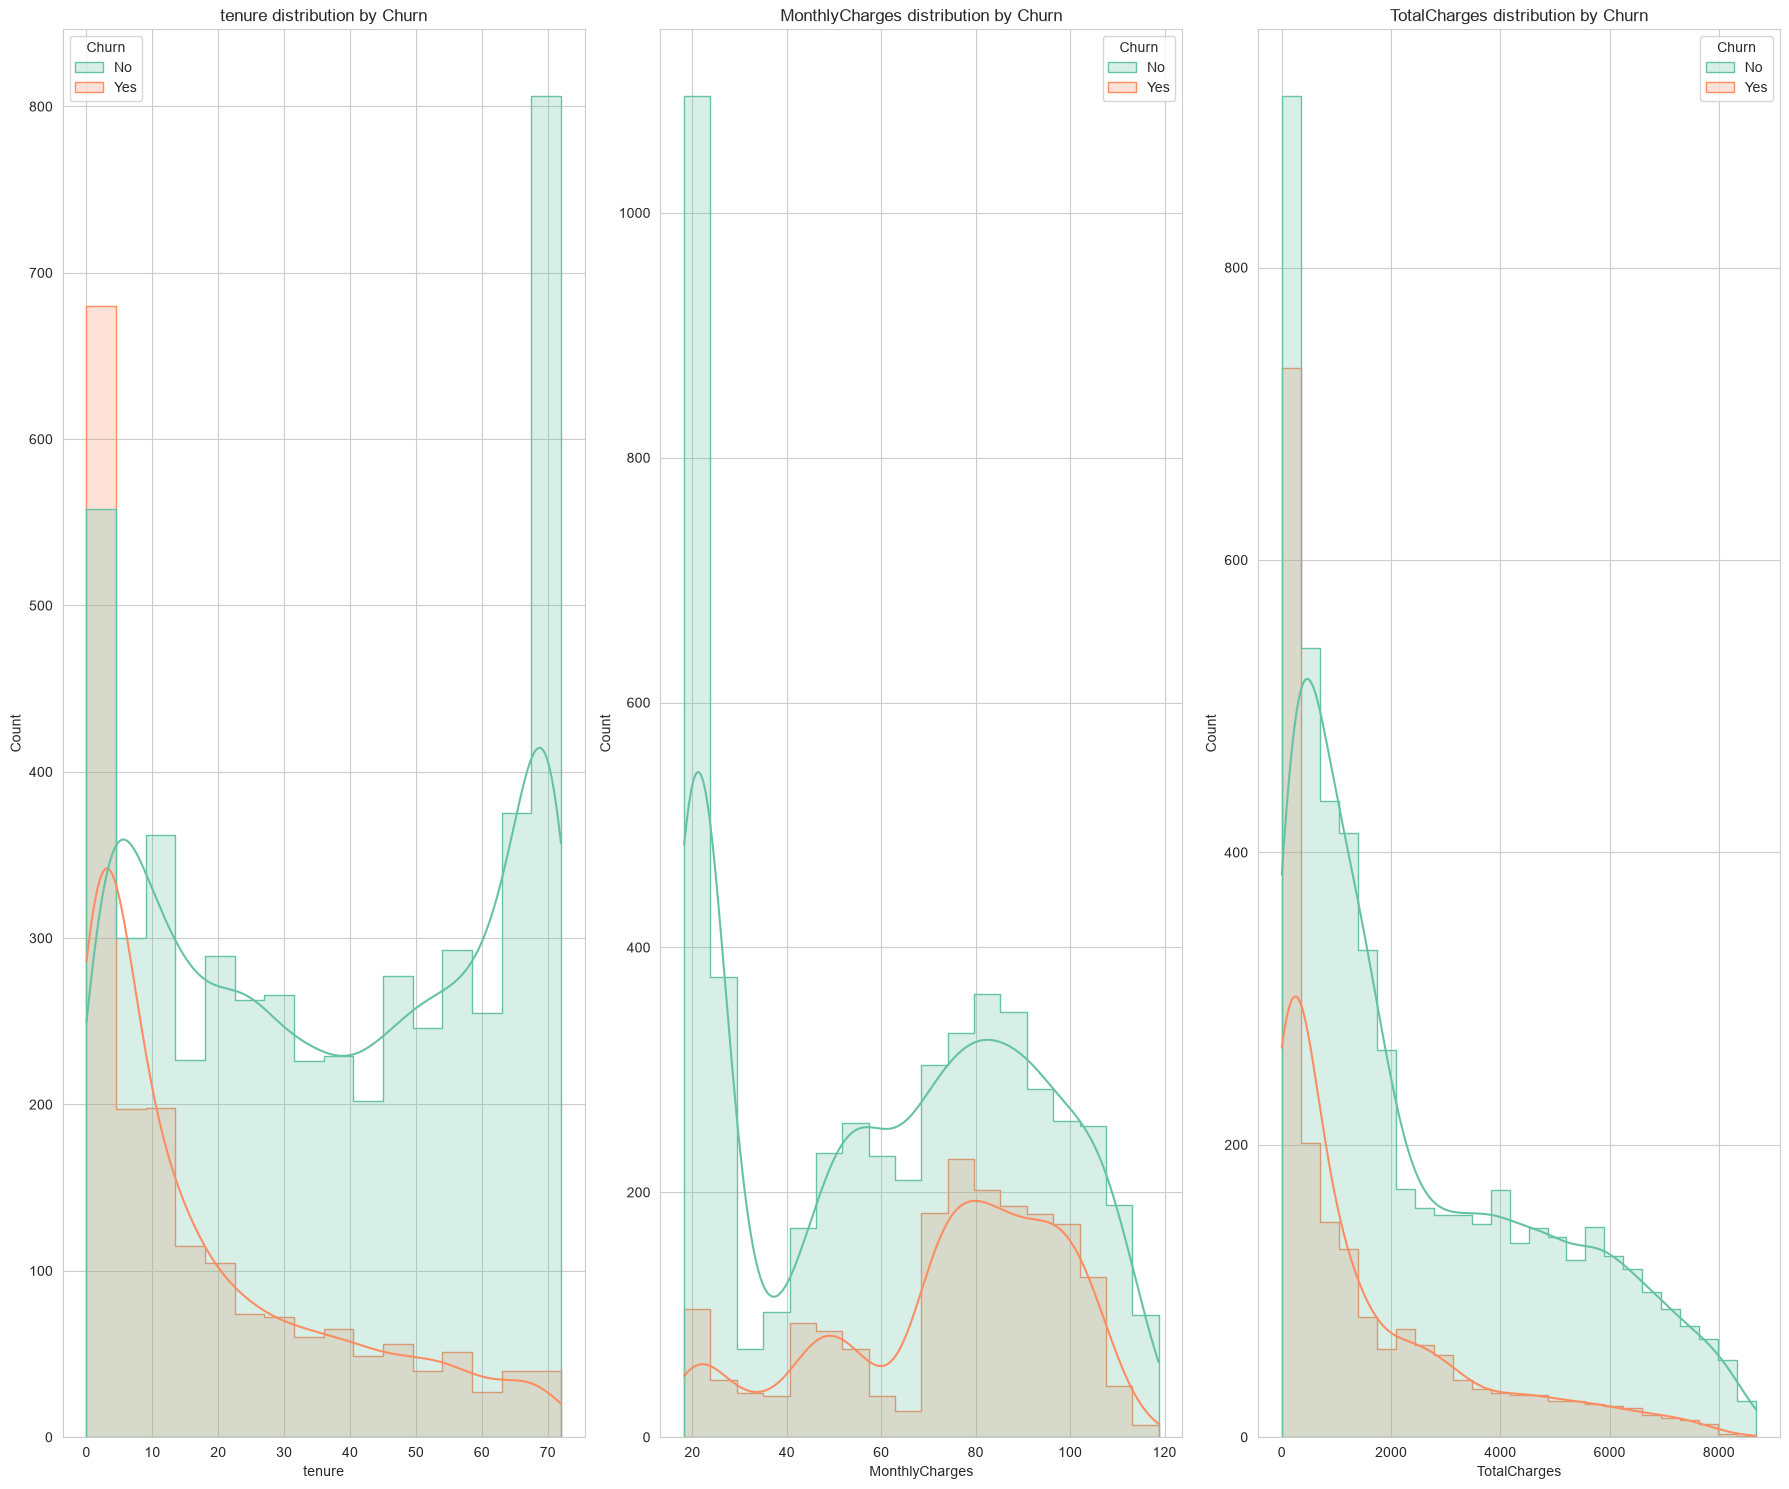

In [11]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# One row of 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 15))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax,
                 palette='Set2', element='step')
    ax.set_title(f'{col} distribution by Churn')

plt.tight_layout()
plt.show()

# The actual churn drivers (categorical)

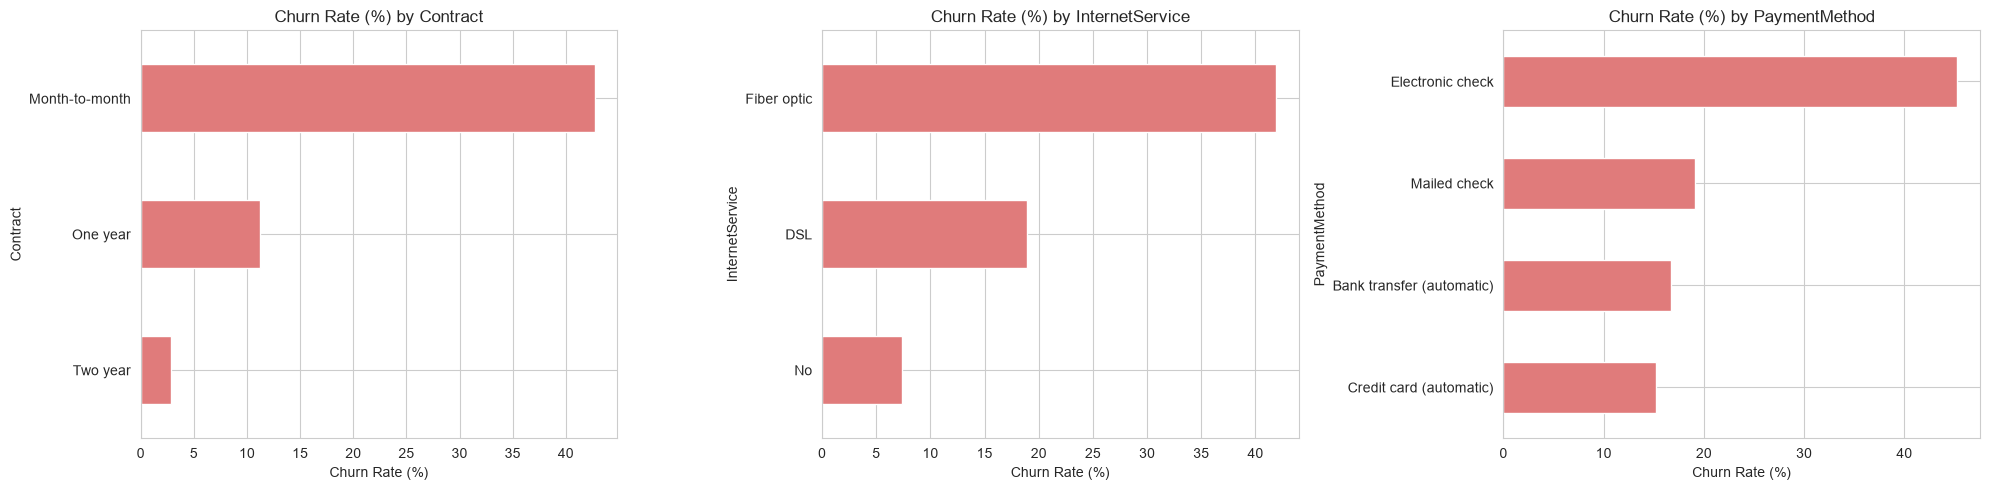

In [ ]:
cat_drivers = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col in zip(axes, cat_drivers):
    # Row-wise %: within each category, what fraction churned?
    rate = pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'] * 100
    rate.sort_values().plot(kind='barh', ax=ax, color='#e07b7b')
    ax.set_title(f'Churn Rate (%) by {col}')
    ax.set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

# Confirm the numeric relationships (correlation)

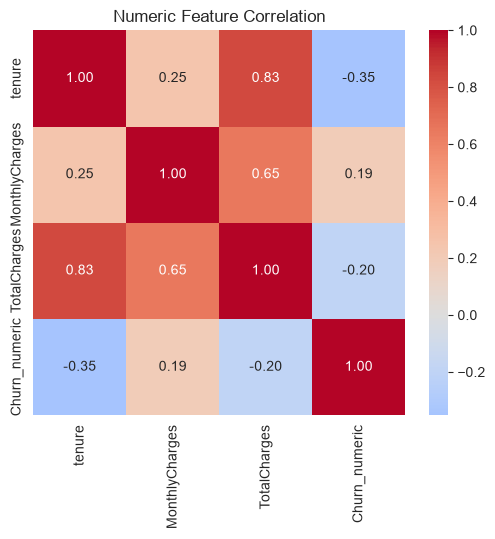

In [13]:
# Temporary numeric version of the target, just for correlation (EDA only)
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Numeric Feature Correlation')
plt.show()

## 📌 Key EDA Findings (→ feed into modeling)

**Target:** Imbalanced ~26.5% churn / 73.5% retain.
→ Baseline-to-beat = 73.5% accuracy. Judge models on **Precision, Recall, F1, ROC-AUC**, not accuracy. Consider class weighting.

**Strongest churn drivers:**
- **Contract**: month-to-month churns ~43% vs ~3% for two-year (biggest signal).
- **Tenure**: new customers (0–10 months) churn heavily.
- **PaymentMethod**: electronic check churns ~45%.
- **InternetService**: fiber optic churns ~42%.
- **MonthlyCharges**: higher charges → more churn.

**Modeling notes:**
- `tenure` & `TotalCharges` strongly correlated (~0.83) — multicollinearity.
- Drop `customerID` (identifier, no signal).
- Features are interpretable → model will be explainable.